<div style="background-color: #f0f4ff; padding: 16px 20px; border-left: 5px solid #4a6fa5; border-radius: 4px;">
<h2 style="margin: 0 0 8px 0;">Lab 3: Image Recognition</h2>
<p style="margin: 0 0 16px 0; font-size: 13px; color: #555;">Adapted from Chan, Yee Kit, Erica Lai, and Yu Chen. "Teaching Tip: Teaching Undergraduate IS Students Hands-on Generative AI Development Skills." <em>Journal of Information Systems Education</em> 37(1), 2026.</p>
<hr style="border: none; border-top: 1px solid #ccc; margin-bottom: 16px;">
<b>First time in a coding environment?</b> You do not need to write any code — just run it and read the output. Click the play button or press <b>Shift + Enter</b>. Go top to bottom. If something breaks, go to <b>Runtime → Restart and run all</b>.<br><br>
<b>Table of contents</b> — Click the list icon on the left sidebar to jump between sections.<br>
<b>Two cell types</b> — Code cells have a play button. Text cells (like this one) have instructions.<br>
<b>Run order matters</b> — Skipping a cell may cause errors in later ones.
</div>

<div>
<h3>What is Image Recognition?</h3>

<p>In Labs 1 and 2, the AI read text — a prompt, a resident message. The input was always words.</p>

<p>A resident sees illegal dumping on their street. To report it they need to open an app, find the right category, type a description, add a location. Most don't bother. The city never finds out.</p>

<p>Image Recognition means the AI can read images the same way it reads text. You upload a photo and the AI identifies the problem, rates the urgency, and names the city department that should respond — automatically.</p>

<p><strong>Labs 1–3 progression:</strong></p>
<table style="border-collapse:collapse;">
  <tbody>
    <tr style="background-color:#fafafa;"><td style="border:1px solid #ccc; padding:8px 16px;">Lab 1</td><td style="border:1px solid #ccc; padding:8px 16px;">AI responds to prompts — and you control how</td></tr>
    <tr><td style="border:1px solid #ccc; padding:8px 16px;">Lab 2</td><td style="border:1px solid #ccc; padding:8px 16px;">AI extracts structured data from messy text</td></tr>
    <tr style="background-color:#f0f4ff; font-weight:bold;"><td style="border:1px solid #ccc; padding:8px 16px;">Lab 3 ← you are here</td><td style="border:1px solid #ccc; padding:8px 16px;">AI reads images and generates civic reports</td></tr>
  </tbody>
</table>
</div>

# Setting Up Your Development Environment
- Install the required libraries.

In [ ]:
!pip install -q google-generativeai Pillow

# Importing and Initializing Gemini

Store your API key in Colab Secrets:
 1. Click the key icon in the left sidebar
 2. Add a secret named `GEMINI_API_KEY`
 3. Paste your API key as the value
 4. Toggle "Notebook access" to ON

Get your free API key at: https://aistudio.google.com

In [ ]:
import google.generativeai as genai
from google.colab import userdata, files
from IPython.display import display
from PIL import Image as PILImage
import time
import os

genai.configure(api_key=userdata.get('GEMINI_API_KEY'))
print("Gemini initialized successfully.")

/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)


Gemini initialized successfully.


# Part 1: Upload Your Image

You need an image to analyze. Choose one of these options:

- **Option A** — Take a photo on your phone and upload it here.
- **Option B** — Use any existing image from your computer or downloaded from the internet.
- **Option C (recommended)** — Photograph something in your neighborhood that you believe represents a real civic or social issue. This could be a pothole, graffiti, overgrown vegetation blocking a sign, poor lighting on a path, a broken bench in a park — anything you personally think is a problem.

Supported formats: jpg, jpeg, png, gif, webp — maximum 20 MB.

> **Why Option C?** The reflection at the end of this lab asks you to compare what *you* see in the image to what the *AI* sees. Choosing a real issue you care about makes that comparison meaningful.

Saving 05152024_1-graffiti-earlier_174259.webp to 05152024_1-graffiti-earlier_174259.webp
Uploaded: 05152024_1-graffiti-earlier_174259.webp
Image size: 780x520 pixels


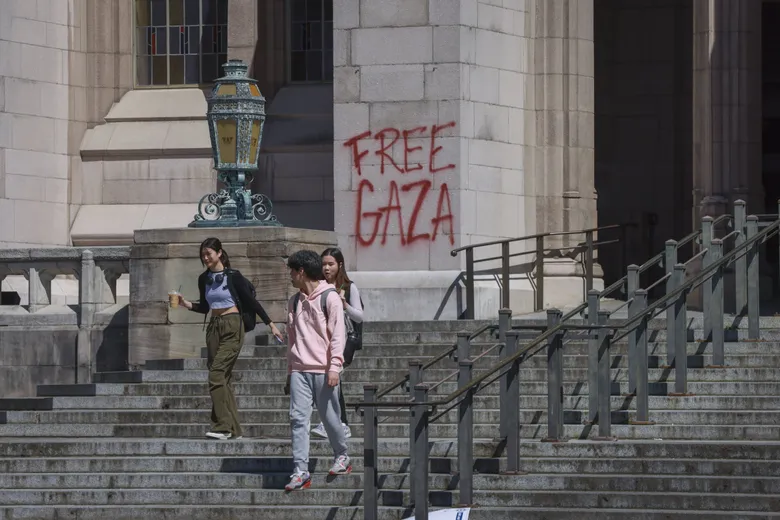

In [ ]:
# Upload your image from your computer.
uploaded = files.upload()

# Get the filename of the uploaded file.
image_filename = list(uploaded.keys())[0]

# Display the uploaded image so you can see what the model will analyze.
img = PILImage.open(image_filename)
print(f"Uploaded: {image_filename}")
print(f"Image size: {img.size[0]}x{img.size[1]} pixels")
display(img)

# Part 2: Core Analysis Function

This function sends both the image and a question to Gemini.
This is called **multimodal input** — the model processes image and text together.

Run this cell to define the function. No output yet — that comes in Part 3.

In [ ]:
def analyze_image(image_path, question):
    """
    Send an image + a question to Gemini and return the response.
    Returns: (response_text, usage_metadata)
    """
    m = genai.GenerativeModel(model_name="gemini-2.5-flash")
    img = PILImage.open(image_path)
    response = m.generate_content([question, img])
    time.sleep(12)  # stays under free tier rate limit
    return response.text, response.usage_metadata

print("analyze_image() function defined. Ready to use in Parts 3 and 4.")

analyze_image() function defined. Ready to use in Parts 3 and 4.


# Part 3: Four Standard Civic Analysis Questions

San Jose's 311 system triages every report using four key questions:

1. What is the problem?
2. What are the public health or safety implications?
3. How urgent is this?
4. Which department or service should respond?

Run the cell below to see how Gemini answers all four for your image.
This may take up to two minutes due to rate limits — that is expected.

In [ ]:
civic_questions = [
    ("PROBLEM", "Random graffiti tagged on campus from unknown source."),
    ("IMPACT", "The graffiti could negatively affect campus appearance and make students feel less safe. It may also lead to increased maintenance costs and encourage further vandalism if not addressed."),
    ("URGENCY", "MEDIUM. While graffiti is not an immediate physical danger, it is a form of vandalism that affects campus environment and student perception of safety. If it is part of repeated tagging or expanding vandalism, it could escalate and should be addressed promptly."),
    ("ACTION", "SJSU janitors should be notified to clean or remove the graffiti, and SJSU Campus Police (UPD) should document the incident and check nearby cameras if available.")
]

civic_results = {"answers": {}, "total_tokens": 0}

for label, question in civic_questions:
    print(f"--- {label} ---")
    answer, usage = analyze_image(image_filename, question)
    civic_results["answers"][label] = answer
    civic_results["total_tokens"] += usage.total_token_count
    print(answer)
    print()

print(f"--- Total tokens used: {civic_results['total_tokens']} ---")
print("Running on Gemini free tier — no cost.")

--- PROBLEM ---
Red spray paint boldly displays "FREE GAZA" on a prominent stone wall of a grand university building, likely indicating an unauthorized act of graffiti. In the foreground, several students walk down a wide, majestic stone staircase on a sunny day, with an ornate lamppost visible to the left. The scene captures a moment of daily campus life juxtaposed with a clear political statement.

--- IMPACT ---
This image captures a daytime scene on what appears to be a university or institutional campus, featuring a large, stately stone building with a grand staircase. The most striking element is the prominent red graffiti "FREE GAZA" spray-painted on a corner section of the building's light-colored stone facade.

**Detailed Description:**

*   **The Setting:** The background is dominated by a multi-story building constructed from large, light-grey or off-white stone blocks, suggesting a classical or neo-classical architectural style. A tall, ornate, dark-colored lamp post with a

# Part 4: Ask Your Own Question

Now that you have seen the standard four-question analysis, ask the model something specific
that is relevant to your own image or your team's project scenario.

Examples:
- `"Is there any graffiti or vandalism visible in this image?"`
- `"Does this sidewalk appear to be in need of repair?"`
- `"Are there any accessibility barriers visible for wheelchair users?"`
- `"What time of day does this appear to have been taken?"`
- `"What would it cost to fix what you see here?"`

In [ ]:
custom_question = input("\nWhat does the graffiti say?: ")
custom_result, custom_usage = analyze_image(image_filename, custom_question)

print("\n--- Response ---")
print(custom_result)
print(f"\nTokens used: {custom_usage.total_token_count}")


What does the graffiti say?: free gaza

--- Response ---
The image shows a large stone building with the phrase "FREE GAZA" spray-painted in red letters on its side. In the foreground, a wide stone staircase with multiple metal railings descends. Three young people are walking down the stairs; one woman on the left holds a drink, and a man and another woman follow behind her. An ornate, tall lamppost stands to the left of the graffiti, against the building. The scene appears to be outdoors on a sunny day.

Tokens used: 538


# Part 5: Reflection — What the AI Sees vs. What You See

**Write your answers directly in this text cell. Double-click to edit it.**

This is the most important part of the lab. Read your AI outputs carefully before answering.

---

**Question 1 — Comparison:**
Look at the AI's PROBLEM and URGENCY answers.
Do they match your own assessment of the image?
Describe at least one specific thing the AI got right and one thing it missed or misjudged.

Yes, the AI does match my own asssment of the image. The one thing AI got right is that the graffiti is red. One thing it misjudged is like the placement of the persepective. I'm not really sure how to explain it but AI says foreground when its just a odd way of stating the persective of where the grafiti is

---

**Question 2 — What the model was trained to see:**
The AI's analysis reflects patterns from its training data.
If you photographed something that is a real problem in your community but
looks ordinary (for example, a sidewalk that has never had curb cuts for wheelchair users),
would the AI recognize it as a problem? What does this tell you about whose problems
get encoded into AI systems — and whose don't?

I think that AI would not recgnize it as a problem because it wouldn't be programed to know what's right and what's wrong. This tells me that AI could be biased based on who encodes the systems.


---

**Question 3 — Deployment decision:**
Imagine this system is deployed: a resident uploads a photo to the San Jose 311 app,
the AI analyzes it automatically, and a work order is generated without any human review.
For what types of images or issues would this work well?
For what types would automated routing be a mistake?
Who should make that call, and how?

I think AI would be decent at describing the image however it cannot tell the exact pinpoint location. I think something that could help is access to location or having the person who uploaded the image stating where it happened. Who ever made the app should have that call if they want to implement a rule that makes the rights to not disclose information if they don't want to.